In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import joblib

warnings.filterwarnings("ignore")

### Load processed data

In [56]:
df_clean = pd.read_csv("../data/processed/heart_clean.csv")

### Load clean data for reference

In [57]:
x_train_processed = pd.read_csv("../data/processed/x_train_processed.csv").values
x_test_processed = pd.read_csv("../data/processed/x_test_processed.csv").values
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze().values
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze().values

In [58]:
df_clean.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [59]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.2 KB


In [60]:
df_clean.shape

(302, 14)

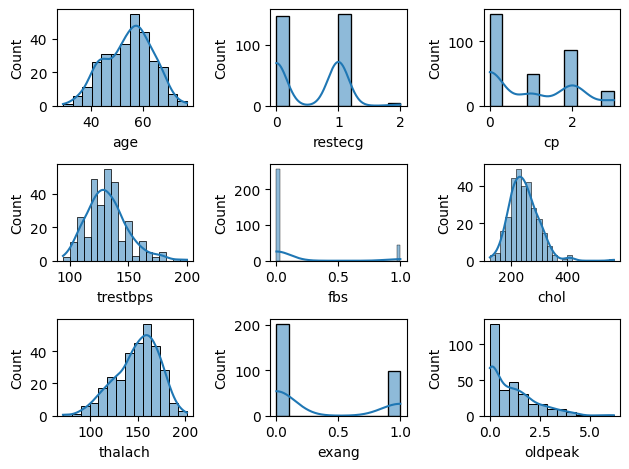

In [61]:
def plotting(var,num):
    plt.subplot(3,3,num)
    sns.histplot(df_clean[var],kde = True)

plotting('age',1)
plotting('restecg',2)
plotting('cp',3)
plotting('trestbps',4)
plotting('fbs',5)
plotting('chol', 6)
plotting('thalach',7)
plotting('exang',8)
plotting('oldpeak',9)


plt.tight_layout()    

In [62]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.compose import ColumnTransformer

In [63]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(random_state=42,probability=True),
    "KNN": KNeighborsClassifier(n_neighbors=7)
}



In [64]:
results = []

In [65]:
for name, model in models.items():
    model.fit(x_train_processed, y_train)
    y_pred = model.predict(x_test_processed)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append({"Model": name, "acciracy_score" : round(accuracy,4), "f1_score": round(f1,4)})
    # print(name)
    # print("Accuracy:", accuracy_score(y_test, y_pred))
    # print("F1 Score:", f1_score(y_test, y_pred))
    # print(classification_report(y_test, y_pred))
    # print("-" * 60)

In [66]:
results

[{'Model': 'Logistic Regression',
  'acciracy_score': 0.8361,
  'f1_score': 0.8485},
 {'Model': 'Naive Bayes', 'acciracy_score': 0.8197, 'f1_score': 0.8406},
 {'Model': 'Decision Tree', 'acciracy_score': 0.6721, 'f1_score': 0.6774},
 {'Model': 'SVM', 'acciracy_score': 0.8033, 'f1_score': 0.8182},
 {'Model': 'KNN', 'acciracy_score': 0.8197, 'f1_score': 0.8254}]

In [70]:
os.makedirs("../models", exist_ok=True)

best_model = LogisticRegression(max_iter=5000)
best_model.fit(x_train_processed, y_train)

joblib.dump(best_model, "../models/logistic_regression_model.pkl")
joblib.dump(df_clean.columns.tolist(), "../models/feature_columns.pkl")

print("Model saved successfully")

Model saved successfully
